https://huggingface.co/docs/transformers/main/en/model_doc/depth_anything_v2

In [1]:
import matplotlib.pyplot as plt

In [6]:
from transformers import pipeline
from PIL import Image
import requests

# load pipe
pipe = pipeline(task="depth-estimation", model="depth-anything/Depth-Anything-V2-Small-hf")

# load image
url = 'http://images.cocodataset.org/val2017/000000039769.jpg'
image = Image.open(requests.get(url, stream=True).raw)

# inference
depth = pipe(image)["depth"]

# plot
plt.imshow(depth)

RuntimeError: GET was unable to find an engine to execute this computation

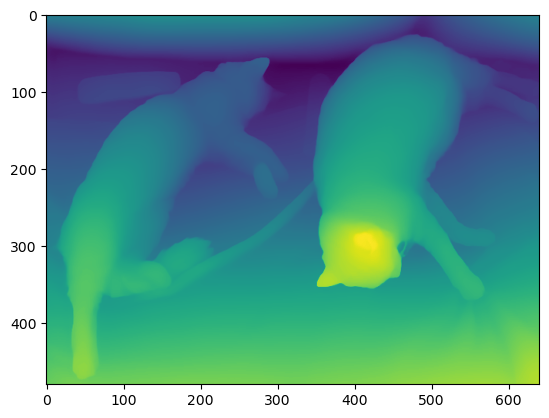

In [2]:
from transformers import AutoImageProcessor, AutoModelForDepthEstimation
import torch
import numpy as np
from PIL import Image
import requests

url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(url, stream=True).raw)

image_processor = AutoImageProcessor.from_pretrained("depth-anything/Depth-Anything-V2-Small-hf")
model = AutoModelForDepthEstimation.from_pretrained("depth-anything/Depth-Anything-V2-Small-hf")

# prepare image for the model
inputs = image_processor(images=image, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)
    predicted_depth = outputs.predicted_depth

# interpolate to original size
prediction = torch.nn.functional.interpolate(
    predicted_depth.unsqueeze(1),
    size=image.size[::-1],
    mode="bicubic",
    align_corners=False,
)

# visualize the prediction
output = prediction.squeeze().cpu().numpy()
formatted = (output * 255 / np.max(output)).astype("uint8")
depth = Image.fromarray(formatted)

# Plot the scaled depth image
plt.imshow(depth)

# Investigate Depth Anything v2

In [ ]:
from transformers import AutoImageProcessor, AutoModelForDepthEstimation
depth_est_model = AutoModelForDepthEstimation.from_pretrained("depth-anything/Depth-Anything-V2-Small-hf")

In [ ]:
from torchviz import make_dot
import torch

# Dummy input for the model
dummy_input = torch.randn(1, 3, 224, 224)

# Forward pass
output = depth_est_model(dummy_input)

print(output)
# Check if output is a tensor, if not convert it to a tensor
if isinstance(output, dict):
    output = output.predicted_depth  # Adjust this key based on the actual output structure

# Visualize the model
make_dot(output, params=dict(depth_est_model.named_parameters())).render("depth_est_model_structure", format="png")

In [ ]:
depth_est_model.backbone.encoder.layer[-1]

In [ ]:
import torch.onnx
# Export the model to ONNX
onnx_path = "depth_est_model.onnx"
torch.onnx.export(depth_est_model, dummy_input, onnx_path, opset_version=11)